In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
from skbio import DistanceMatrix
from skbio.tree import nj
from skbio.tree import upgma
from skbio.tree import bme
from skbio import TreeNode

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import gridspec

from Bio import Phylo
import numpy as np

import glob,os,copy,requests
from io import StringIO
import requests

import baltic as bt


Pruning the tree so it only has the species of interest.

In [3]:
primate_tree = TreeNode.read("../data/Craig_Kumar_Hedges_final_timetree.nwk")
primate_tree

<TreeNode, name: unnamed, internal node count: 453, tips count: 455>

In [4]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

In [5]:
df_l = []
for s in metadata_20x_filt.species_genotyping.unique():
    f_c = len(metadata_20x_filt.loc[metadata_20x_filt.gSEX == "F"])
    if f_c == 0:
        continue
    # Read het df
    pi_df_path = "../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)
    if os.path.exists("../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        print("Not present:", s)
        continue
    df_l.append(pi_df)
all_pi_df = pd.concat(df_l)

In [6]:
# Credit to Vasili Pankratov for consolidating this data
mating_vas = pd.read_excel("../data/PrimatePhenotypes_december.xlsx", sheet_name=8)
mating_vas

,binomial_name,Monogamous,Polygynous,Polygynandrous,Polyandrous,lowSC,highSC,consensus,comment,Juliana_Christina,genus_comment
0,Allenopithecus_nigroviridis,0,0,1,0,0,1,Polygynandrous,NaN,NaN,NaN
1,Allocebus_trichotis,2,1,0,0,3,0,Monogamous,NaN,NaN,NaN
2,Allochrocebus_lhoesti,0,3,0,0,3,0,Polygynous,NaN,NaN,NaN
3,Allochrocebus_preussi,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
4,Allochrocebus_solatus,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
311,Trachypithecus_phayrei,0,2,1,0,2,1,NaN,conflicting,NaN,NaN
312,Trachypithecus_pileatus,0,2,0,0,2,0,Polygynous,NaN,NaN,NaN
313,Trachypithecus_selangorensis,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
314,Varecia_rubra,0,1,1,0,1,1,NaN,conflicting,NaN,NaN


In [7]:
mating_vas.loc[mating_vas.Polyandrous >= 1]

,binomial_name,Monogamous,Polygynous,Polygynandrous,Polyandrous,lowSC,highSC,consensus,comment,Juliana_Christina,genus_comment
39,Callibella_humilis,3,1,0,1,4,1,NaN,conflicting,NaN,NaN
44,Callithrix_flaviceps,2,1,0,1,3,1,NaN,conflicting,NaN,NaN
46,Callithrix_jacchus,2,0,0,2,2,2,NaN,conflicting,NaN,NaN
47,Callithrix_kuhlii,0,0,0,2,0,2,Polyandrous,double-check,NaN,NaN
51,Cebuella_pygmaea,4,0,0,1,4,1,Monogamous,conflicting,NaN,NaN
140,Leontocebus_fuscicollis,1,0,0,2,1,2,NaN,conflicting,NaN,NaN
142,Leontocebus_nigricollis,1,0,1,1,1,2,NaN,conflicting,NaN,NaN
145,Leontopithecus_chrysopygus,2,0,0,1,2,1,Monogamous,conflicting,NaN,NaN
146,Leontopithecus_rosalia,4,0,0,1,4,1,Monogamous,conflicting,NaN,NaN
211,Piliocolobus_badius,1,0,1,1,1,2,Polygynandrous,conflicting,NaN,NaN


In [8]:
mating_vas.loc[mating_vas.comment == "conflicting"]

,binomial_name,Monogamous,Polygynous,Polygynandrous,Polyandrous,lowSC,highSC,consensus,comment,Juliana_Christina,genus_comment
6,Alouatta_caraya,0,1,2,0,1,2,NaN,conflicting,NaN,NaN
8,Alouatta_guariba,0,2,1,0,2,1,NaN,conflicting,NaN,NaN
12,Alouatta_palliata,0,2,2,0,2,2,NaN,conflicting,NaN,NaN
13,Alouatta_pigra,0,2,1,0,2,1,NaN,conflicting,NaN,NaN
15,Alouatta_seniculus,0,3,1,0,3,1,NaN,conflicting,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
300,Trachypithecus_crepusculus,0,1,1,0,1,1,Polygynous,conflicting,NaN,NaN
310,Trachypithecus_obscurus,0,3,1,0,3,1,NaN,conflicting,NaN,NaN
311,Trachypithecus_phayrei,0,2,1,0,2,1,NaN,conflicting,NaN,NaN
314,Varecia_rubra,0,1,1,0,1,1,NaN,conflicting,NaN,NaN


In [9]:
mating_vas["Strategy_count"] = mating_vas[["Monogamous", "Polygynous", "Polygynandrous", "Polyandrous"]].sum(axis=1)
mating_vas["Monogamous_strategy"] = mating_vas["Monogamous"]/mating_vas["Strategy_count"]
mating_vas["Polygynous_strategy"] = mating_vas["Polygynous"]/mating_vas["Strategy_count"]
mating_vas["Polygynandrous_strategy"] = mating_vas["Polygynandrous"]/mating_vas["Strategy_count"]
mating_vas["Polyandrous_strategy"] = mating_vas["Polyandrous"]/mating_vas["Strategy_count"]
mating_vas

,binomial_name,Monogamous,Polygynous,Polygynandrous,Polyandrous,lowSC,highSC,consensus,comment,Juliana_Christina,genus_comment,Strategy_count,Monogamous_strategy,Polygynous_strategy,Polygynandrous_strategy,Polyandrous_strategy
0,Allenopithecus_nigroviridis,0,0,1,0,0,1,Polygynandrous,NaN,NaN,NaN,1,0.000000,0.000000,1.000000,0.0
1,Allocebus_trichotis,2,1,0,0,3,0,Monogamous,NaN,NaN,NaN,3,0.666667,0.333333,0.000000,0.0
2,Allochrocebus_lhoesti,0,3,0,0,3,0,Polygynous,NaN,NaN,NaN,3,0.000000,1.000000,0.000000,0.0
3,Allochrocebus_preussi,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN,1,0.000000,1.000000,0.000000,0.0
4,Allochrocebus_solatus,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN,1,0.000000,1.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311,Trachypithecus_phayrei,0,2,1,0,2,1,NaN,conflicting,NaN,NaN,3,0.000000,0.666667,0.333333,0.0
312,Trachypithecus_pileatus,0,2,0,0,2,0,Polygynous,NaN,NaN,NaN,2,0.000000,1.000000,0.000000,0.0
313,Trachypithecus_selangorensis,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN,1,0.000000,1.000000,0.000000,0.0
314,Varecia_rubra,0,1,1,0,1,1,NaN,conflicting,NaN,NaN,2,0.000000,0.500000,0.500000,0.0


In [10]:
mating_vas.loc[mating_vas.Strategy_count >= 1]

,binomial_name,Monogamous,Polygynous,Polygynandrous,Polyandrous,lowSC,highSC,consensus,comment,Juliana_Christina,genus_comment,Strategy_count,Monogamous_strategy,Polygynous_strategy,Polygynandrous_strategy,Polyandrous_strategy
0,Allenopithecus_nigroviridis,0,0,1,0,0,1,Polygynandrous,NaN,NaN,NaN,1,0.000000,0.000000,1.000000,0.0
1,Allocebus_trichotis,2,1,0,0,3,0,Monogamous,NaN,NaN,NaN,3,0.666667,0.333333,0.000000,0.0
2,Allochrocebus_lhoesti,0,3,0,0,3,0,Polygynous,NaN,NaN,NaN,3,0.000000,1.000000,0.000000,0.0
3,Allochrocebus_preussi,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN,1,0.000000,1.000000,0.000000,0.0
4,Allochrocebus_solatus,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN,1,0.000000,1.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311,Trachypithecus_phayrei,0,2,1,0,2,1,NaN,conflicting,NaN,NaN,3,0.000000,0.666667,0.333333,0.0
312,Trachypithecus_pileatus,0,2,0,0,2,0,Polygynous,NaN,NaN,NaN,2,0.000000,1.000000,0.000000,0.0
313,Trachypithecus_selangorensis,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN,1,0.000000,1.000000,0.000000,0.0
314,Varecia_rubra,0,1,1,0,1,1,NaN,conflicting,NaN,NaN,2,0.000000,0.500000,0.500000,0.0


<Axes: xlabel='Polygynandrous_strategy', ylabel='Count'>

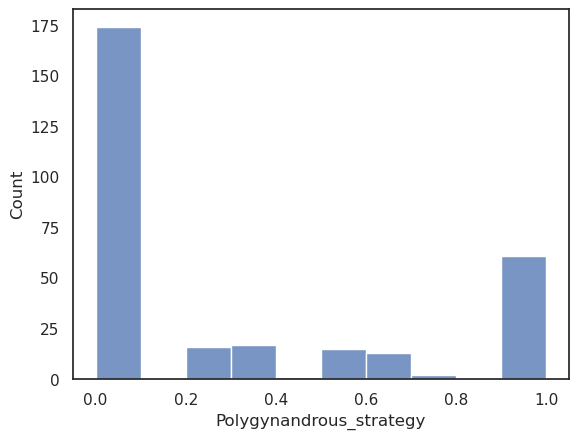

In [11]:
sns.histplot(mating_vas, x="Polygynandrous_strategy")

In [12]:
mean_pi_df = all_pi_df.loc[all_pi_df.callable_frac >= 0.5].groupby(["species","chr_type"])[["pi"]].mean()
mean_pi_df = mean_pi_df.reset_index().pivot(columns="chr_type", index="species", values="pi")
all_pi_df_aut = all_pi_df.loc[all_pi_df.chr_type == "aut"]
chrx_pi_df_aut = all_pi_df.loc[all_pi_df.chr_type == "chrX"]
mean_pi_df = mean_pi_df.reset_index()
mean_pi_df["CV_aut"] = (all_pi_df_aut.groupby(["species"])[["pi"]].std() / all_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]
CV_x_df = (chrx_pi_df_aut.groupby(["species"])[["pi"]].std() / chrx_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()
mean_pi_df["CV_x"] = mean_pi_df.species.map(dict(zip(CV_x_df.species, CV_x_df.pi)))
mean_pi_df["Autosomal Pi per base"] = mean_pi_df.aut/100000
mean_pi_df["ChrX Pi per base"] = mean_pi_df.chrX/100000
mean_pi_df["X_a_ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["X/A ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["binomial_name"] = [x[:-4] for x in mean_pi_df.species]
mean_pi_df["Strategy_count"] = mean_pi_df.binomial_name.map(dict(zip(mating_vas.binomial_name, mating_vas.Strategy_count)))
mean_pi_df["Monogamous_strategy"] = mean_pi_df.binomial_name.map(dict(zip(mating_vas.binomial_name, mating_vas.Monogamous_strategy)))
mean_pi_df["Polygynous_strategy"] = mean_pi_df.binomial_name.map(dict(zip(mating_vas.binomial_name, mating_vas.Polygynous_strategy)))
mean_pi_df["Polygynandrous_strategy"] = mean_pi_df.binomial_name.map(dict(zip(mating_vas.binomial_name, mating_vas.Polygynandrous_strategy)))
mean_pi_df["Polyandrous_strategy"] = mean_pi_df.binomial_name.map(dict(zip(mating_vas.binomial_name, mating_vas.Polyandrous_strategy)))


In [13]:
mean_pi_df

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,Strategy_count,Monogamous_strategy,Polygynous_strategy,Polygynandrous_strategy,Polyandrous_strategy
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.429676,0.842548,0.001380,0.000761,0.551049,0.551049,Allenopithecus_nigroviridis,1.0,0.0,0.0,1.0,0.0
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.512099,0.921961,0.002712,0.000983,0.362366,0.362366,Allochrocebus_lhoesti,3.0,0.0,1.0,0.0,0.0
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.698784,0.959003,0.002649,0.001059,0.399758,0.399758,Allochrocebus_preussi,1.0,0.0,1.0,0.0,0.0
3,Allochrocebus_solatus_ssp,302.877750,NaN,0.712146,NaN,0.003029,NaN,NaN,NaN,Allochrocebus_solatus,1.0,0.0,1.0,0.0,0.0
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.266829,0.268274,0.005102,0.003662,0.717838,0.717838,Alouatta_belzebul,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.712469,0.680886,0.000655,0.000380,0.580929,0.580929,Trachypithecus_poliocephalus,NaN,NaN,NaN,NaN,NaN
247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.430623,0.522426,0.002328,0.001347,0.578665,0.578665,Trachypithecus_vetulus,NaN,NaN,NaN,NaN,NaN
248,Varecia_rubra_ssp,151.034928,NaN,0.762300,NaN,0.001510,NaN,NaN,NaN,Varecia_rubra,2.0,0.0,0.5,0.5,0.0
249,Varecia_variegata_ssp,211.144432,120.002801,0.422388,0.614984,0.002111,0.001200,0.568345,0.568345,Varecia_variegata,5.0,0.6,0.0,0.2,0.2


In [14]:
species_with_x = mean_pi_df.loc[~mean_pi_df["X/A ratio"].isna()]

In [15]:
# 166 species with an observed strategy.
species_with_x.loc[species_with_x.Strategy_count > 0]

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,Strategy_count,Monogamous_strategy,Polygynous_strategy,Polygynandrous_strategy,Polyandrous_strategy
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.429676,0.842548,0.001380,0.000761,0.551049,0.551049,Allenopithecus_nigroviridis,1.0,0.0,0.000000,1.000000,0.0
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.512099,0.921961,0.002712,0.000983,0.362366,0.362366,Allochrocebus_lhoesti,3.0,0.0,1.000000,0.000000,0.0
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.698784,0.959003,0.002649,0.001059,0.399758,0.399758,Allochrocebus_preussi,1.0,0.0,1.000000,0.000000,0.0
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.266829,0.268274,0.005102,0.003662,0.717838,0.717838,Alouatta_belzebul,1.0,0.0,1.000000,0.000000,0.0
6,Alouatta_discolor_ssp,206.429698,108.086733,0.604936,0.623321,0.002064,0.001081,0.523601,0.523601,Alouatta_discolor,1.0,0.0,1.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,Trachypithecus_geei_ssp,48.520157,25.451977,1.153415,1.234334,0.000485,0.000255,0.524565,0.524565,Trachypithecus_geei,1.0,0.0,1.000000,0.000000,0.0
243,Trachypithecus_obscurus_ssp,172.448006,75.047018,0.521609,0.621238,0.001724,0.000750,0.435186,0.435186,Trachypithecus_obscurus,4.0,0.0,0.750000,0.250000,0.0
244,Trachypithecus_phayrei_ssp,220.856149,125.290763,0.351241,0.440333,0.002209,0.001253,0.567296,0.567296,Trachypithecus_phayrei,3.0,0.0,0.666667,0.333333,0.0
245,Trachypithecus_pileatus_ssp,110.758378,59.386733,0.762625,0.921115,0.001108,0.000594,0.536183,0.536183,Trachypithecus_pileatus,2.0,0.0,1.000000,0.000000,0.0


In [16]:
species_list = ["{} {}".format(x.split("_")[0], x.split("_")[1]) for x in species_with_x.species.unique()]
species_with_x["Binomial name"] = species_list
species_list

/tmp/36779554/ipykernel_1624414/2230923322.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x["Binomial name"] = species_list


['Allenopithecus nigroviridis',
 'Allochrocebus lhoesti',
 'Allochrocebus preussi',
 'Alouatta belzebul',
 'Alouatta discolor',
 'Alouatta juara',
 'Alouatta macconnelli',
 'Alouatta palliata',
 'Alouatta seniculus',
 'Aotus azarai',
 'Aotus griseimembra',
 'Aotus nancymaae',
 'Aotus trivirgatus',
 'Aotus vociferans',
 'Arctocebus calabarensis',
 'Ateles belzebuth',
 'Ateles chamek',
 'Ateles geoffroyi',
 'Ateles marginatus',
 'Ateles paniscus',
 'Avahi peyrierasi',
 'Brachyteles hypoxanthus',
 'Cacajao ayresi',
 'Cacajao calvus',
 'Cacajao hosomi',
 'Cacajao melanocephalus',
 'Callimico goeldii',
 'Callithrix jacchus',
 'Cebuella niveiventris',
 'Cebuella pygmaea',
 'Cebus albifrons',
 'Cebus imitator',
 'Cebus olivaceus',
 'Cebus unicolor',
 'Cercocebus atys',
 'Cercocebus chrysogaster',
 'Cercopithecus ascanius',
 'Cercopithecus campbelli',
 'Cercopithecus cephus',
 'Cercopithecus denti',
 'Cercopithecus hamlyni',
 'Cercopithecus mitis',
 'Cercopithecus mona',
 'Cercopithecus neglec

In [17]:
trimmed_list = []
for node in primate_tree.tips():
    if node.name in species_list:
        trimmed_list.append(node.name)

In [18]:
# Three species don't have a phylogenetic placement.
for s in species_list:
    if s not in trimmed_list:
        print(s)

Chiropotes sagulatus
Eulemur collaris
Microcebus jonahi


In [19]:
primate_tree.shear(trimmed_list).write("../data/trimmed_primate_tree.nwk")

'../data/trimmed_primate_tree.nwk'

In [20]:
species_with_x

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,Strategy_count,Monogamous_strategy,Polygynous_strategy,Polygynandrous_strategy,Polyandrous_strategy,Binomial name
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.429676,0.842548,0.001380,0.000761,0.551049,0.551049,Allenopithecus_nigroviridis,1.0,0.0,0.0,1.0,0.0,Allenopithecus nigroviridis
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.512099,0.921961,0.002712,0.000983,0.362366,0.362366,Allochrocebus_lhoesti,3.0,0.0,1.0,0.0,0.0,Allochrocebus lhoesti
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.698784,0.959003,0.002649,0.001059,0.399758,0.399758,Allochrocebus_preussi,1.0,0.0,1.0,0.0,0.0,Allochrocebus preussi
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.266829,0.268274,0.005102,0.003662,0.717838,0.717838,Alouatta_belzebul,1.0,0.0,1.0,0.0,0.0,Alouatta belzebul
6,Alouatta_discolor_ssp,206.429698,108.086733,0.604936,0.623321,0.002064,0.001081,0.523601,0.523601,Alouatta_discolor,1.0,0.0,1.0,0.0,0.0,Alouatta discolor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Trachypithecus_pileatus_ssp,110.758378,59.386733,0.762625,0.921115,0.001108,0.000594,0.536183,0.536183,Trachypithecus_pileatus,2.0,0.0,1.0,0.0,0.0,Trachypithecus pileatus
246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.712469,0.680886,0.000655,0.000380,0.580929,0.580929,Trachypithecus_poliocephalus,NaN,NaN,NaN,NaN,NaN,Trachypithecus poliocephalus
247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.430623,0.522426,0.002328,0.001347,0.578665,0.578665,Trachypithecus_vetulus,NaN,NaN,NaN,NaN,NaN,Trachypithecus vetulus
249,Varecia_variegata_ssp,211.144432,120.002801,0.422388,0.614984,0.002111,0.001200,0.568345,0.568345,Varecia_variegata,5.0,0.6,0.0,0.2,0.2,Varecia variegata


In [ ]:
# Variation based on a gallery example
tree = bt.loadNewick("../data/trimmed_primate_tree.nwk")
#tree.sortBranches()
tree.drawTree()
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 25))
ax.set_ylim(-3,tree.ySpan+3)
ax.set_xlim(-0.1,tree.treeHeight+0.1)
ax.set_yticks([])
ax.set_yticklabels([])

target_func=lambda k: k.is_leaf() ## which branches will be annotated
text_func=lambda k: "  "+k.name ## what text is plotted. Added two spaces, x_attr somehow fails
kwargs={'va':'center','ha':'left','size': 8} ## kwargs for text

tree.addText(ax,target=target_func,text=text_func,**kwargs) ## text will use a different x attribute 


# Plot the tree
tree.plotTree(ax)
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
plt.show()

In [22]:
species_with_x_and_tree = species_with_x.loc[species_with_x["Binomial name"].isin(trimmed_list)]
species_with_x_and_tree['Binomial name'] = pd.Categorical(species_with_x_and_tree['Binomial name'], categories=trimmed_list, ordered=True)

/tmp/36779554/ipykernel_1624414/3840624021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree['Binomial name'] = pd.Categorical(species_with_x_and_tree['Binomial name'], categories=trimmed_list, ordered=True)


In [23]:
species_with_x_and_tree.sort_values(["Binomial name"])

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,Strategy_count,Monogamous_strategy,Polygynous_strategy,Polygynandrous_strategy,Polyandrous_strategy,Binomial name
161,Pan_troglodytes_ssp,175.943834,120.666763,0.478890,0.435661,0.001759,0.001207,0.685825,0.685825,Pan_troglodytes,3.0,0.000000,0.000000,1.000000,0.0,Pan troglodytes
160,Pan_paniscus_ssp,84.169136,55.852667,0.613750,0.565961,0.000842,0.000559,0.663577,0.663577,Pan_paniscus,2.0,0.000000,0.000000,1.000000,0.0,Pan paniscus
90,Gorilla_gorilla_ssp,188.938321,104.608068,0.625608,0.821158,0.001889,0.001046,0.553663,0.553663,Gorilla_gorilla,3.0,0.000000,1.000000,0.000000,0.0,Gorilla gorilla
89,Gorilla_beringei_ssp,112.538515,50.857913,0.785494,1.125244,0.001125,0.000509,0.451916,0.451916,Gorilla_beringei,1.0,0.000000,1.000000,0.000000,0.0,Gorilla beringei
190,Pongo_pygmaeus_ssp,190.461962,68.777545,0.587609,0.888452,0.001905,0.000688,0.361109,0.361109,Pongo_pygmaeus,5.0,0.000000,0.600000,0.400000,0.0,Pongo pygmaeus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Galago_senegalensis_ssp,330.173987,193.620951,0.382056,0.566934,0.003302,0.001936,0.586421,0.586421,Galago_senegalensis,4.0,0.000000,0.750000,0.250000,0.0,Galago senegalensis
86,Galago_moholi_ssp,163.429494,63.883573,0.655587,1.112770,0.001634,0.000639,0.390894,0.390894,Galago_moholi,3.0,0.000000,1.000000,0.000000,0.0,Galago moholi
159,Otolemur_garnettii_ssp,224.297772,119.587633,0.582165,0.964966,0.002243,0.001196,0.533165,0.533165,Otolemur_garnettii,3.0,0.000000,0.333333,0.666667,0.0,Otolemur garnettii
158,Otolemur_crassicaudatus_ssp,160.722120,114.098904,0.430408,0.523526,0.001607,0.001141,0.709914,0.709914,Otolemur_crassicaudatus,3.0,0.333333,0.666667,0.000000,0.0,Otolemur crassicaudatus


Generating the tree with colored tips based on X/A ratio.

In [24]:
tree = bt.loadNewick("../data/trimmed_primate_tree.nwk")

for leaf in tree.getExternal():
    name = leaf.name  # or leaf.numName if using Nexus numeric names
    leaf.traits["X/A Ratio"] = species_with_x_and_tree.loc[species_with_x_and_tree.binomial_name == name, "X/A ratio"].values[0]
    leaf.traits["Autosomal Diversity"] = species_with_x_and_tree.loc[species_with_x_and_tree.binomial_name == name, "Autosomal Pi per base"].values[0]
    leaf.traits["Autosomal Diversity per 100kb"] = species_with_x_and_tree.loc[species_with_x_and_tree.binomial_name == name, "Autosomal Pi per base"].values[0]*100000
    leaf.traits["ChrX Diversity"] = species_with_x_and_tree.loc[species_with_x_and_tree.binomial_name == name, "ChrX Pi per base"].values[0]
    leaf.traits["ChrX Diversity per 100kb"] = species_with_x_and_tree.loc[species_with_x_and_tree.binomial_name == name, "ChrX Pi per base"].values[0]*100000

In [25]:
leaf.traits

{'X/A Ratio': 0.723107114325249,
 'Autosomal Diversity': 0.0014215243561791007,
 'Autosomal Diversity per 100kb': 142.15243561791007,
 'ChrX Diversity': 0.001027914375139727,
 'ChrX Diversity per 100kb': 102.7914375139727}

In [26]:
# Setting up the palette
palette = sns.color_palette("coolwarm_r", as_cmap=True)
# Alternative palettes
#palette = sns.color_palette("flare", as_cmap=True)
mean_XA = species_with_x_and_tree["X/A ratio"].mean()

Text(0.5, 1.0, 'X/A Ratio')

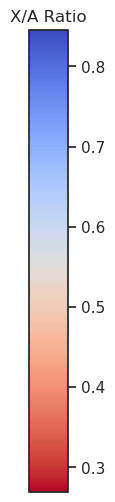

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

vmin = species_with_x_and_tree["X/A ratio"].min()
vmax = species_with_x_and_tree["X/A ratio"].max()

fig, ax = plt.subplots(figsize=(0.5, 6))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=palette, norm=norm),
    cax=ax,
    orientation="vertical",
    ticklocation="right"
)
#cbar.set_label("X/A Ratio", rotation=0, labelpad=10)
ax.set_title("X/A Ratio")


Text(0.5, 1.0, 'X/A Ratio')

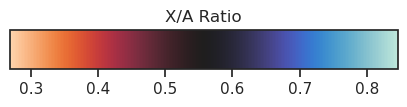

In [28]:
palette = sns.color_palette("icefire_r", as_cmap=True)
vmin = species_with_x_and_tree["X/A ratio"].min()
vmax = species_with_x_and_tree["X/A ratio"].max()

fig, ax = plt.subplots(figsize=(5, 0.5))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=palette, norm=norm),
    cax=ax,
    orientation="horizontal"
)
#cbar.set_label("X/A Ratio", rotation=0, labelpad=10)
ax.set_title("X/A Ratio")


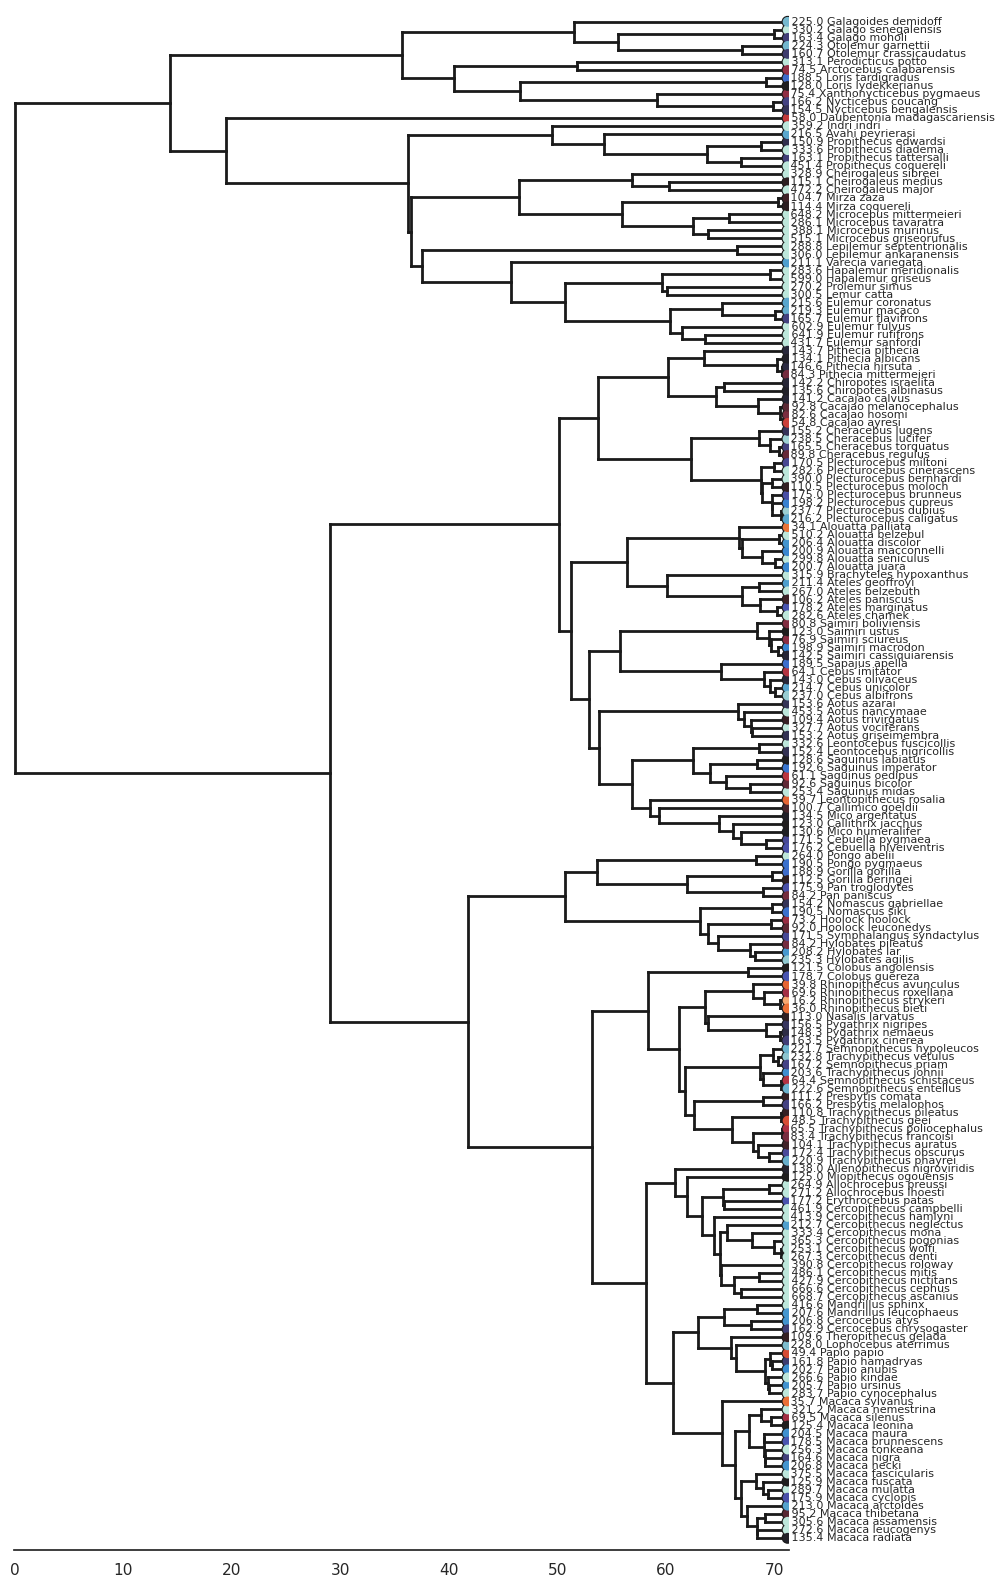

In [29]:
tree.drawTree()
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 20))
ax.set_ylim(-1,tree.ySpan+1)
ax.set_xlim(-0.1,tree.treeHeight+0.1)
ax.set_yticks([])
ax.set_yticklabels([])


target_func=lambda k: k.is_leaf() ## which branches will be annotated
text_func=lambda k: " {:.1f} {} {}".format(k.traits['Autosomal Diversity per 100kb'], k.name.split("_")[0], k.name.split("_")[1]) ## what text is plotted. Added two spaces, x_attr somehow fails
c_func=lambda k: palette(k.traits['Autosomal Diversity per 100kb']/250)

kwargs={'va':'center','ha':'left','size': 8} ## kwargs for text

tree.addText(ax,target=target_func,text=text_func,**kwargs) ## text will use a different x attribute 
tree.plotPoints(ax,size=50,colour=c_func,zorder=100,outline_size=50*1.5)


# Plot the tree
tree.plotTree(ax)
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
plt.show()

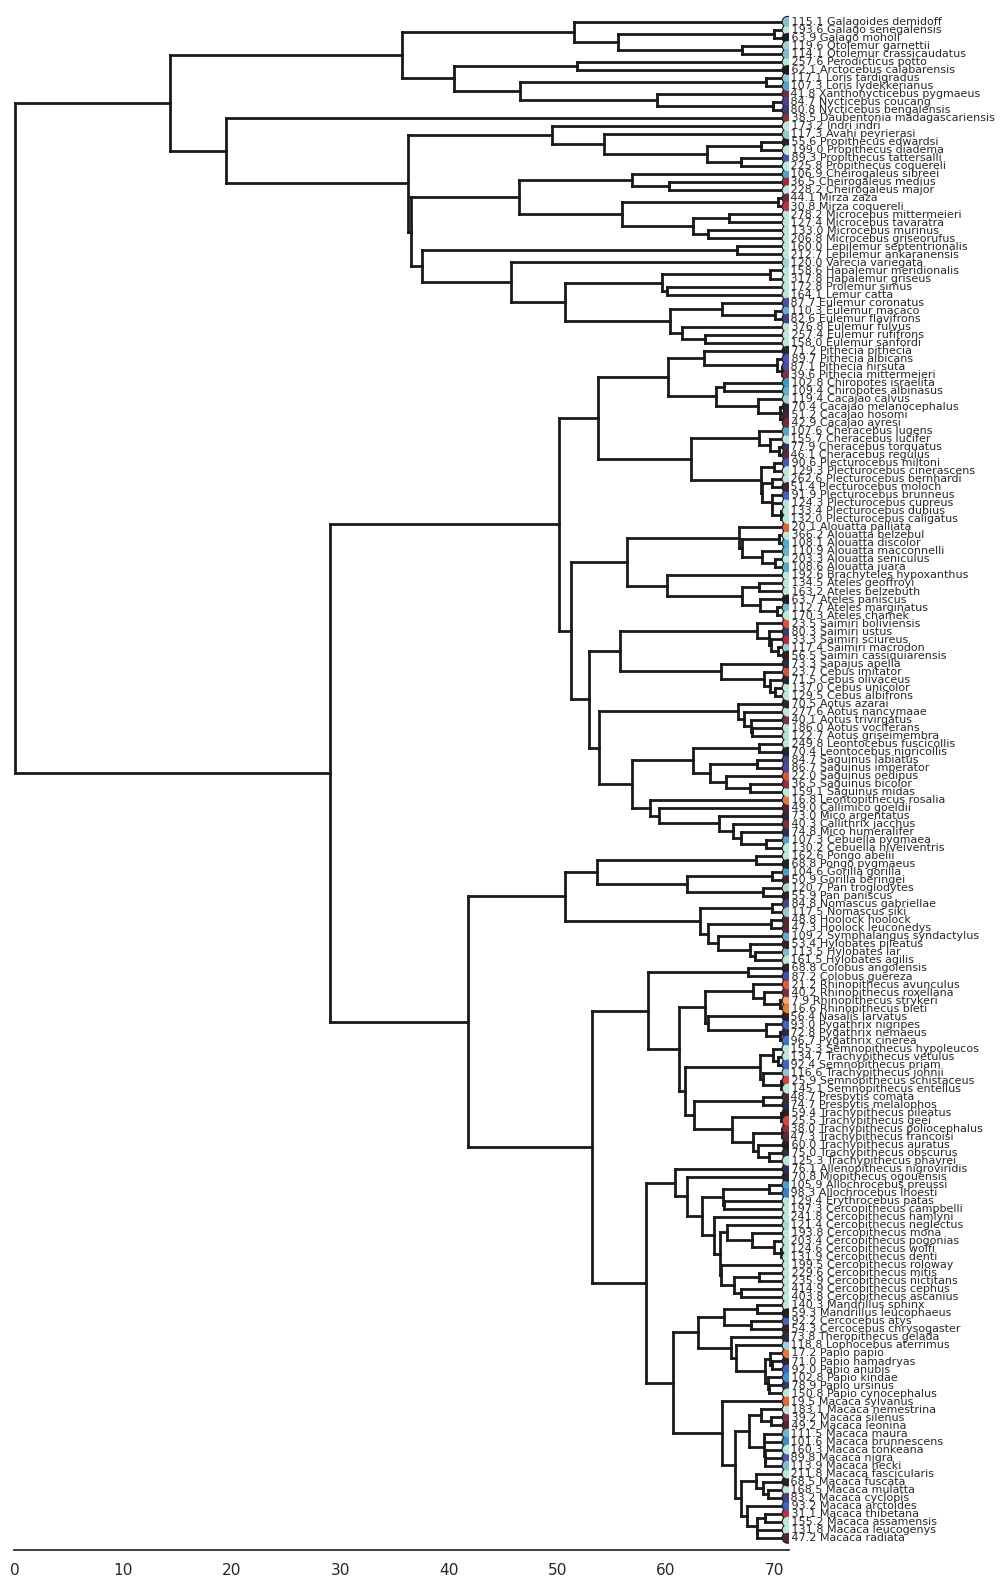

In [30]:
tree.drawTree()
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 20))
ax.set_ylim(-1,tree.ySpan+1)
ax.set_xlim(-0.1,tree.treeHeight+0.1)
ax.set_yticks([])
ax.set_yticklabels([])


target_func=lambda k: k.is_leaf() ## which branches will be annotated
text_func=lambda k: " {:.1f} {} {}".format(k.traits['ChrX Diversity per 100kb'], k.name.split("_")[0], k.name.split("_")[1]) ## what text is plotted. Added two spaces, x_attr somehow fails
c_func=lambda k: palette(k.traits['ChrX Diversity per 100kb']/125)

kwargs={'va':'center','ha':'left','size': 8} ## kwargs for text

tree.addText(ax,target=target_func,text=text_func,**kwargs) ## text will use a different x attribute 
tree.plotPoints(ax,size=50,colour=c_func,zorder=100,outline_size=50*1.5)


# Plot the tree
tree.plotTree(ax)
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
plt.show()

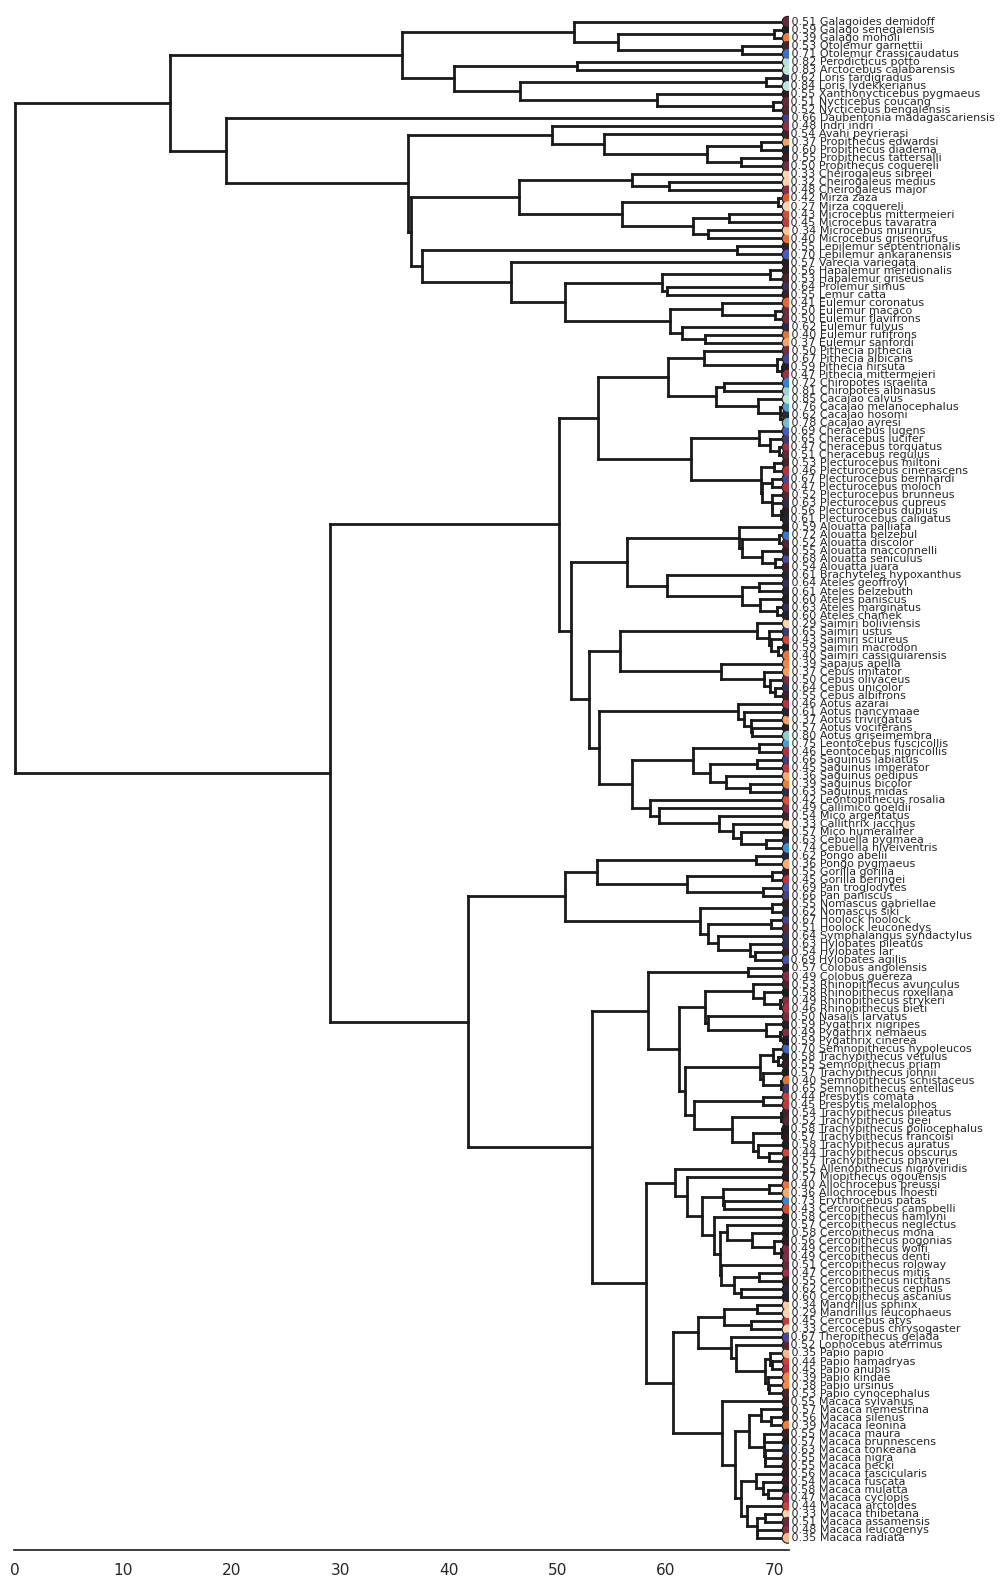

In [31]:
tree.drawTree()
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 20))
ax.set_ylim(-1,tree.ySpan+1)
ax.set_xlim(-0.1,tree.treeHeight+0.1)
ax.set_yticks([])
ax.set_yticklabels([])


target_func=lambda k: k.is_leaf() ## which branches will be annotated
text_func=lambda k: " {:.2f} {} {}".format(k.traits['X/A Ratio'], k.name.split("_")[0], k.name.split("_")[1]) ## what text is plotted. Added two spaces, x_attr somehow fails
c_func=lambda k: palette(k.traits['X/A Ratio']*2-0.66)

kwargs={'va':'center','ha':'left','size': 8} ## kwargs for text

tree.addText(ax,target=target_func,text=text_func,**kwargs) ## text will use a different x attribute 
tree.plotPoints(ax,size=50,colour=c_func,zorder=100,outline_size=50*1.5)


# Plot the tree
tree.plotTree(ax)
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
plt.show()

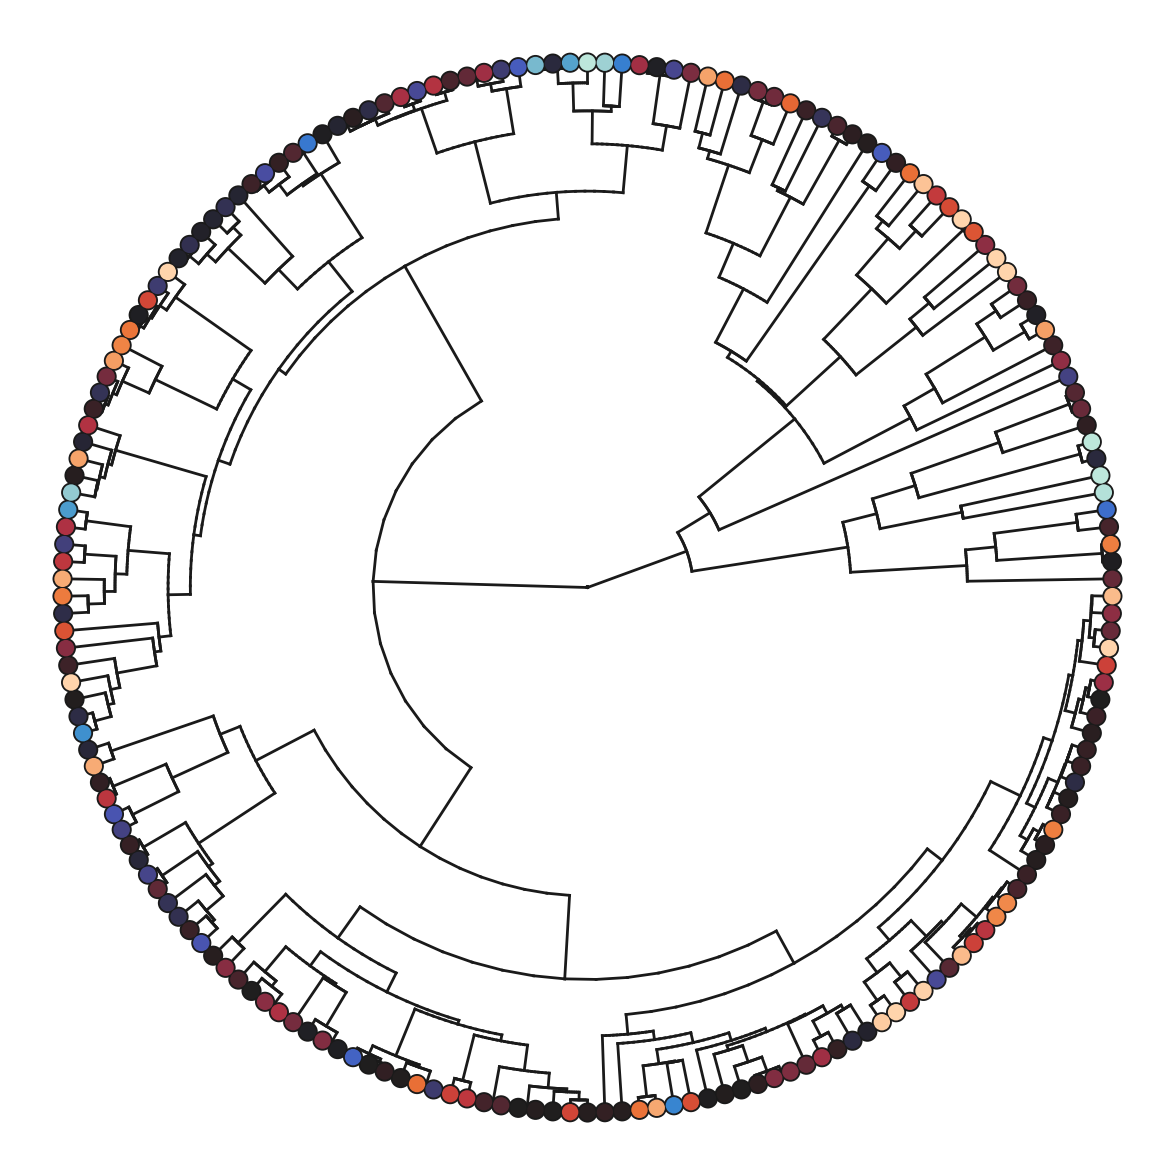

In [32]:
fig = plt.subplots(figsize=(15,15),facecolor='w')

ax = plt.subplot()

c_func=lambda k: palette(k.traits['X/A Ratio']*2-0.66)

tree.plotCircularTree(ax,circStart=0.25,circFrac=1,inwardSpace=0.001*tree.treeHeight) 
tree.plotCircularPoints(ax,circStart=0.25,circFrac=1,colour=c_func,inwardSpace=0.001*tree.treeHeight,
                        size=140,outline_size=140*1.5)

ax.plot()

[ax.spines[loc].set_visible(False) for loc in ax.spines]
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_aspect(1)
plt.show()

Testes imputation.

In [33]:
testes_vas = pd.read_csv("../data/testes_body_residuals.tsv", sep="\t")
testes_vas

,binomial_name,testes_mass_avg,body_mass_avg,residuals
0,Aotus_lemurinus,0.50,895.48,-2.9101
1,Pithecia_pithecia,0.92,1940.00,-2.7275
2,Colobus_guereza,3.21,9963.78,-2.4002
3,Gorilla_gorilla,19.64,171189.33,-2.3514
4,Trachypithecus_francoisi,3.98,7700.00,-1.8575
...,...,...,...,...
98,Macaca_fuscata,72.30,10970.00,2.0064
99,Ateles_paniscus,64.23,8860.00,2.0283
100,Eulemur_cinereiceps,27.23,2029.54,2.1192
101,Mirza_zaza,8.52,293.53,2.1865


<Axes: xlabel='body_mass_avg', ylabel='testes_mass_avg'>

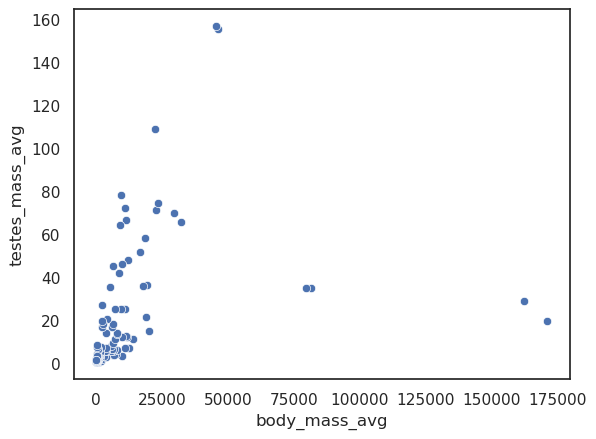

In [34]:
sns.scatterplot(testes_vas, y="testes_mass_avg", x="body_mass_avg")

In [35]:
# Great apes are heavy!
testes_vas.loc[testes_vas.body_mass_avg > 40000]

,binomial_name,testes_mass_avg,body_mass_avg,residuals
3,Gorilla_gorilla,19.64,171189.33,-2.3514
8,Gorilla_beringei,28.96,162500.00,-1.7441
29,Pongo_abelii,34.87,81661.71,-0.8557
31,Pongo_pygmaeus,34.97,79715.85,-0.8299
93,Pan_troglodytes,155.52,46174.48,1.8154
94,Pan_paniscus,156.87,45368.75,1.8438


<Axes: xlabel='log_body', ylabel='log_testes'>

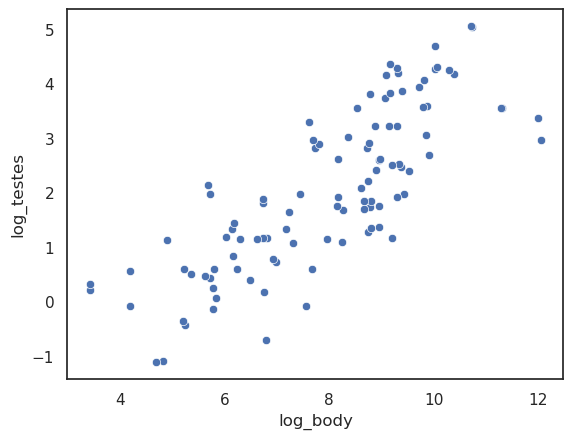

In [36]:
testes_vas["log_body"] = np.log(testes_vas.body_mass_avg)
testes_vas["log_testes"] = np.log(testes_vas.testes_mass_avg)
sns.scatterplot(testes_vas, y="log_testes", x="log_body")

In [37]:
testes_vas

,binomial_name,testes_mass_avg,body_mass_avg,residuals,log_body,log_testes
0,Aotus_lemurinus,0.50,895.48,-2.9101,6.797360,-0.693147
1,Pithecia_pithecia,0.92,1940.00,-2.7275,7.570443,-0.083382
2,Colobus_guereza,3.21,9963.78,-2.4002,9.206712,1.166271
3,Gorilla_gorilla,19.64,171189.33,-2.3514,12.050525,2.977568
4,Trachypithecus_francoisi,3.98,7700.00,-1.8575,8.948976,1.381282
...,...,...,...,...,...,...
98,Macaca_fuscata,72.30,10970.00,2.0064,9.302920,4.280824
99,Ateles_paniscus,64.23,8860.00,2.0283,9.089302,4.162470
100,Eulemur_cinereiceps,27.23,2029.54,2.1192,7.615564,3.304319
101,Mirza_zaza,8.52,293.53,2.1865,5.681980,2.142416


In [38]:
import statsmodels.formula.api as smf
glm_results = smf.gls(formula = "log_testes ~ log_body",
                      data=testes_vas).fit()
glm_results.resid

0     -2.017146
1     -1.890586
2     -1.663659
3     -1.629847
4     -1.287554
         ...   
98     1.390761
99     1.405925
100    1.468913
101    1.515569
102    1.553852
Length: 103, dtype: float64

Imputation is done by calculating the mean body size and testes size of the last three common ancestors with any node information.

In [39]:
primate_tree_trim = TreeNode.read("../data/trimmed_primate_tree.nwk")
d_species_imputed_sizes_body = {}
d_species_imputed_sizes_testes = {}
for tip in primate_tree.tips():
    ancestor_dict = {}
    for ancestor_node in tip.ancestors():
        ancestor_height = ancestor_node.height()[0]
        if ancestor_height <= 10:
            for tips in ancestor_node.tips():
                if tips.name not in ancestor_dict:
                    ancestor_dict[tips.name] = ancestor_height
    ancestor_weight_sum = 0
    ancestor_body_sum = 0
    ancestor_testes_sum = 0
    for ancestor in ancestor_dict:
        binomial_ancestor = ancestor.replace(" ", "_")
        if binomial_ancestor in testes_vas.binomial_name.values:
            ancestor_weight_sum += 1/ancestor_dict[ancestor]
            ancestor_body_sum += testes_vas.loc[testes_vas.binomial_name == binomial_ancestor]["body_mass_avg"].iloc[0]/ancestor_dict[ancestor]
            ancestor_testes_sum += testes_vas.loc[testes_vas.binomial_name == binomial_ancestor]["testes_mass_avg"].iloc[0]/ancestor_dict[ancestor]
    if ancestor_weight_sum > 0:
        d_species_imputed_sizes_body[tip.name.replace(" ", "_")] = ancestor_body_sum/ancestor_weight_sum
        d_species_imputed_sizes_testes[tip.name.replace(" ", "_")] = ancestor_testes_sum/ancestor_weight_sum

In [50]:
d_species_imputed_sizes_testes

{'Pan_troglodytes': 130.48178851174936,
 'Pan_paniscus': 130.48178851174936,
 'Homo_sapiens': 100.36164276807978,
 'Gorilla_gorilla': 42.173621495327104,
 'Gorilla_beringei': 42.173621495327104,
 'Pongo_tapanuliensis': 34.9246992481203,
 'Pongo_pygmaeus': 34.9246992481203,
 'Pongo_abelii': 34.919999999999995,
 'Hylobates_albibarbis': 6.472147685173319,
 'Hylobates_agilis': 6.472147685173319,
 'Hylobates_muelleri': 6.575881718096434,
 'Hylobates_klossii': 6.6138983640340046,
 'Hylobates_moloch': 6.621180753739033,
 'Hylobates_lar': 6.6495613249776175,
 'Hylobates_pileatus': 6.763324572930354,
 'Symphalangus_syndactylus': 7.367499999999999,
 'Hoolock_tianxing': 7.367500000000001,
 'Hoolock_leuconedys': 7.367500000000001,
 'Hoolock_hoolock': 7.367500000000001,
 'Nomascus_nasutus': 7.3675,
 'Nomascus_hainanus': 7.3675,
 'Nomascus_gabriellae': 7.3675,
 'Nomascus_annamensis': 7.3675,
 'Nomascus_siki': 7.3675,
 'Nomascus_leucogenys': 7.3675,
 'Nomascus_concolor': 7.3675,
 'Cercocebus_torquatu

In [41]:
body_l, testes_l = [], []
for s in species_with_x_and_tree.binomial_name:
    if s in testes_vas.binomial_name.values:
        body_l.append(testes_vas.loc[testes_vas.binomial_name == s]["body_mass_avg"].iloc[0])
        testes_l.append(testes_vas.loc[testes_vas.binomial_name == s]["testes_mass_avg"].iloc[0])
    elif s in d_species_imputed_sizes_body:
        body_l.append(d_species_imputed_sizes_body[s])
        testes_l.append(d_species_imputed_sizes_testes[s])
    else:
        body_l.append(np.nan)
        testes_l.append(np.nan)

In [42]:
species_with_x_and_tree["imputed_body"] = body_l
species_with_x_and_tree["imputed_testes"] = testes_l

/tmp/36779554/ipykernel_1624414/2015257800.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree["imputed_body"] = body_l
/tmp/36779554/ipykernel_1624414/2015257800.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree["imputed_testes"] = testes_l


/tmp/36779554/ipykernel_1624414/2457701587.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree["log_body"] = np.log(species_with_x_and_tree.imputed_body)
/tmp/36779554/ipykernel_1624414/2457701587.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree["log_testes"] = np.log(species_with_x_and_tree.imputed_testes)


<Axes: xlabel='log_body', ylabel='log_testes'>

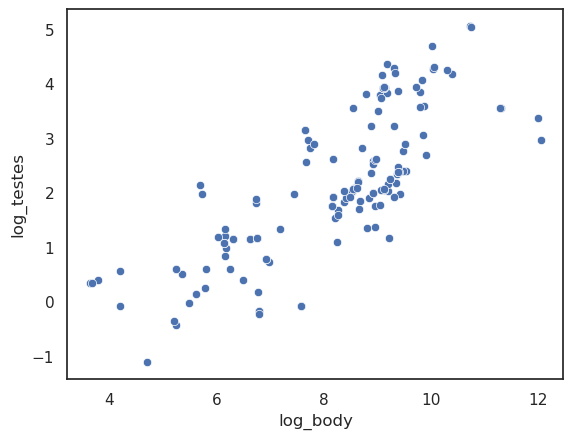

In [43]:
species_with_x_and_tree["log_body"] = np.log(species_with_x_and_tree.imputed_body)
species_with_x_and_tree["log_testes"] = np.log(species_with_x_and_tree.imputed_testes)
sns.scatterplot(species_with_x_and_tree, y="log_testes", x="log_body")

In [48]:
glm_results = smf.gls(formula = "log_testes ~ log_body",
                      data=species_with_x_and_tree).fit()
species_with_x_and_tree["testes_residual"] = glm_results.resid
species_with_x_and_tree

/tmp/36779554/ipykernel_1624414/1875921752.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree["testes_residual"] = glm_results.resid


chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,...,Monogamous_strategy,Polygynous_strategy,Polygynandrous_strategy,Polyandrous_strategy,Binomial name,imputed_body,imputed_testes,log_body,log_testes,testes_residual
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.429676,0.842548,0.001380,0.000761,0.551049,0.551049,Allenopithecus_nigroviridis,...,0.0,0.0,1.0,0.0,Allenopithecus nigroviridis,6130.000000,16.960000,8.720950,2.830858,0.349995
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.512099,0.921961,0.002712,0.000983,0.362366,0.362366,Allochrocebus_lhoesti,...,0.0,1.0,0.0,0.0,Allochrocebus lhoesti,5620.556591,9.222908,8.634186,2.221690,-0.204269
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.698784,0.959003,0.002649,0.001059,0.399758,0.399758,Allochrocebus_preussi,...,0.0,1.0,0.0,0.0,Allochrocebus preussi,5620.556591,9.222908,8.634186,2.221690,-0.204269
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.266829,0.268274,0.005102,0.003662,0.717838,0.717838,Alouatta_belzebul,...,0.0,1.0,0.0,0.0,Alouatta belzebul,7444.540712,13.336267,8.915236,2.590487,-0.013316
6,Alouatta_discolor_ssp,206.429698,108.086733,0.604936,0.623321,0.002064,0.001081,0.523601,0.523601,Alouatta_discolor,...,0.0,1.0,0.0,0.0,Alouatta discolor,7444.540712,13.336267,8.915236,2.590487,-0.013316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Trachypithecus_pileatus_ssp,110.758378,59.386733,0.762625,0.921115,0.001108,0.000594,0.536183,0.536183,Trachypithecus_pileatus,...,0.0,1.0,0.0,0.0,Trachypithecus pileatus,10320.799967,9.456920,9.241917,2.246747,-0.563775
246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.712469,0.680886,0.000655,0.000380,0.580929,0.580929,Trachypithecus_poliocephalus,...,NaN,NaN,NaN,NaN,Trachypithecus poliocephalus,8534.286278,5.952118,9.051847,1.783747,-0.906501
247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.430623,0.522426,0.002328,0.001347,0.578665,0.578665,Trachypithecus_vetulus,...,NaN,NaN,NaN,NaN,Trachypithecus vetulus,11950.858901,10.904189,9.388558,2.389147,-0.514167
249,Varecia_variegata_ssp,211.144432,120.002801,0.422388,0.614984,0.002111,0.001200,0.568345,0.568345,Varecia_variegata,...,0.6,0.0,0.2,0.2,Varecia variegata,3564.840000,13.850000,8.178874,2.628285,0.490439


In [51]:
species_with_x_and_tree.loc[species_with_x_and_tree.imputed_body > 0]

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,...,Monogamous_strategy,Polygynous_strategy,Polygynandrous_strategy,Polyandrous_strategy,Binomial name,imputed_body,imputed_testes,log_body,log_testes,testes_residual
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.429676,0.842548,0.001380,0.000761,0.551049,0.551049,Allenopithecus_nigroviridis,...,0.0,0.000000,1.000000,0.0,Allenopithecus nigroviridis,6130.000000,16.960000,8.720950,2.830858,0.349995
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.512099,0.921961,0.002712,0.000983,0.362366,0.362366,Allochrocebus_lhoesti,...,0.0,1.000000,0.000000,0.0,Allochrocebus lhoesti,5620.556591,9.222908,8.634186,2.221690,-0.204269
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.698784,0.959003,0.002649,0.001059,0.399758,0.399758,Allochrocebus_preussi,...,0.0,1.000000,0.000000,0.0,Allochrocebus preussi,5620.556591,9.222908,8.634186,2.221690,-0.204269
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.266829,0.268274,0.005102,0.003662,0.717838,0.717838,Alouatta_belzebul,...,0.0,1.000000,0.000000,0.0,Alouatta belzebul,7444.540712,13.336267,8.915236,2.590487,-0.013316
6,Alouatta_discolor_ssp,206.429698,108.086733,0.604936,0.623321,0.002064,0.001081,0.523601,0.523601,Alouatta_discolor,...,0.0,1.000000,0.000000,0.0,Alouatta discolor,7444.540712,13.336267,8.915236,2.590487,-0.013316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,Trachypithecus_phayrei_ssp,220.856149,125.290763,0.351241,0.440333,0.002209,0.001253,0.567296,0.567296,Trachypithecus_phayrei,...,0.0,0.666667,0.333333,0.0,Trachypithecus phayrei,9234.200750,7.984310,9.130669,2.077478,-0.662648
245,Trachypithecus_pileatus_ssp,110.758378,59.386733,0.762625,0.921115,0.001108,0.000594,0.536183,0.536183,Trachypithecus_pileatus,...,0.0,1.000000,0.000000,0.0,Trachypithecus pileatus,10320.799967,9.456920,9.241917,2.246747,-0.563775
246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.712469,0.680886,0.000655,0.000380,0.580929,0.580929,Trachypithecus_poliocephalus,...,NaN,NaN,NaN,NaN,Trachypithecus poliocephalus,8534.286278,5.952118,9.051847,1.783747,-0.906501
247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.430623,0.522426,0.002328,0.001347,0.578665,0.578665,Trachypithecus_vetulus,...,NaN,NaN,NaN,NaN,Trachypithecus vetulus,11950.858901,10.904189,9.388558,2.389147,-0.514167


<Axes: xlabel='log_body', ylabel='testes_residual'>

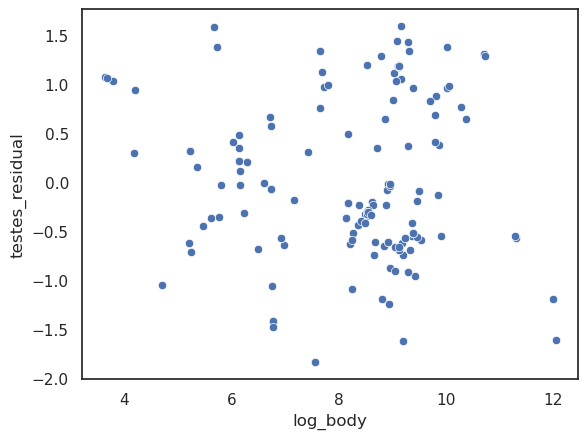

In [45]:
sns.scatterplot(species_with_x_and_tree, y="testes_residual", x="log_body", hue="")

In [47]:
species_with_x_and_tree.to_csv("../data/species_with_x_and_tree.txt", index=False)

Phylogenetic regression.
I use r-ape to generate the covariance matrix based on this tree.
The regressions done in this notebook are only exploratory, the reported regressions are based on the R-markdown file.

In [44]:
primate_tree_trim = TreeNode.read("../data/trimmed_primate_tree.nwk")
primate_tree_trim

<TreeNode, name: unnamed, internal node count: 188, tips count: 190>

In [45]:
covariance_matrix = pd.read_csv("../data/trimmed_cov.csv", header=None)
covariance_matrix

,0,1,2,3,4,5,6,7,8,9,...,180,181,182,183,184,185,186,187,188,189
0,71.23,19.42,19.42,19.42,19.42,19.42,19.42,19.42,19.42,19.42,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,19.42,71.22,60.09,59.67,59.67,50.70,50.70,50.70,50.70,50.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,19.42,60.09,71.22,59.67,59.67,50.70,50.70,50.70,50.70,50.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,19.42,59.67,59.67,71.22,69.63,50.70,50.70,50.70,50.70,50.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,19.42,59.67,59.67,69.63,71.22,50.70,50.70,50.70,50.70,50.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.19,60.19,60.19,60.19,70.97,71.24,70.51,68.47,64.66,64.66
186,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.19,60.19,60.19,60.19,70.51,70.51,71.24,68.47,64.66,64.66
187,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.19,60.19,60.19,60.19,68.47,68.47,68.47,71.23,64.66,64.66
188,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.19,60.19,60.19,60.19,64.66,64.66,64.66,64.66,71.24,65.39


In [46]:
species_with_x_and_tree

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,Strategy_count,Monogamous_strategy,Polygynous_strategy,Polygynandrous_strategy,Polyandrous_strategy,Binomial name
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.429676,0.842548,0.001380,0.000761,0.551049,0.551049,Allenopithecus_nigroviridis,1.0,0.0,0.0,1.0,0.0,Allenopithecus nigroviridis
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.512099,0.921961,0.002712,0.000983,0.362366,0.362366,Allochrocebus_lhoesti,3.0,0.0,1.0,0.0,0.0,Allochrocebus lhoesti
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.698784,0.959003,0.002649,0.001059,0.399758,0.399758,Allochrocebus_preussi,1.0,0.0,1.0,0.0,0.0,Allochrocebus preussi
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.266829,0.268274,0.005102,0.003662,0.717838,0.717838,Alouatta_belzebul,1.0,0.0,1.0,0.0,0.0,Alouatta belzebul
6,Alouatta_discolor_ssp,206.429698,108.086733,0.604936,0.623321,0.002064,0.001081,0.523601,0.523601,Alouatta_discolor,1.0,0.0,1.0,0.0,0.0,Alouatta discolor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Trachypithecus_pileatus_ssp,110.758378,59.386733,0.762625,0.921115,0.001108,0.000594,0.536183,0.536183,Trachypithecus_pileatus,2.0,0.0,1.0,0.0,0.0,Trachypithecus pileatus
246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.712469,0.680886,0.000655,0.000380,0.580929,0.580929,Trachypithecus_poliocephalus,NaN,NaN,NaN,NaN,NaN,Trachypithecus poliocephalus
247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.430623,0.522426,0.002328,0.001347,0.578665,0.578665,Trachypithecus_vetulus,NaN,NaN,NaN,NaN,NaN,Trachypithecus vetulus
249,Varecia_variegata_ssp,211.144432,120.002801,0.422388,0.614984,0.002111,0.001200,0.568345,0.568345,Varecia_variegata,5.0,0.6,0.0,0.2,0.2,Varecia variegata


In [47]:
import statsmodels.formula.api as smf

# First, the simplest regression case
glm_results = smf.gls(formula = "chrX ~ aut", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                   chrX   R-squared:                       0.864
Model:                            GLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     1193.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           2.47e-83
Time:                        11:13:14   Log-Likelihood:                -968.07
No. Observations:                 190   AIC:                             1940.
Df Residuals:                     188   BIC:                             1947.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8416     60.772     -0.014      0.989    -120.724     119.041
aut            0.5526      0.016     34.537      0.000       0.521       0.584
==============================================================================
Omnibus:                       88.174   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1103.930
Skew:                          -1.363   Prob(JB):                    1.93e-240
Kurtosis:                      14.490   Cond. No.                     3.80e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.8e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [48]:
# Tied / no information is set as "unknown"
primary_strategy = []
for a, b, c, d in zip(species_with_x_and_tree.Monogamous_strategy,
                   species_with_x_and_tree.Polygynous_strategy,
                   species_with_x_and_tree.Polygynandrous_strategy,
                   species_with_x_and_tree.Polyandrous_strategy):
    if a > 0.5:
        primary_strategy.append("Monogamous")
    elif b > 0.5:
        primary_strategy.append("Polygynous")
    elif c > 0.5:
        primary_strategy.append("Polygynandrous")
    elif d > 0.5:
        primary_strategy.append("Polyandrous")
    else:
        primary_strategy.append("Unknown")
species_with_x_and_tree["Primary_strategy"] = primary_strategy

/tmp/36627705/ipykernel_140972/1267632417.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree["Primary_strategy"] = primary_strategy


In [49]:
# First, the simplest regression case
glm_results = smf.gls(formula = "chrX ~ aut*Primary_strategy", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                   chrX   R-squared:                       0.878
Model:                            GLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     144.1
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           2.29e-77
Time:                        11:13:14   Log-Likelihood:                -957.57
No. Observations:                 190   AIC:                             1935.
Df Residuals:                     180   BIC:                             1968.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                -21.4480     59.745     -0.359      0.720    -139.339      96.443
Primary_strategy[T.Polyandrous]           39.9821     37.684      1.061      0.290     -34.378     114.342
Primary_strategy[T.Polygynandrous]         5.0892     14.519      0.351      0.726     -23.559      33.738
Primary_strategy[T.Polygynous]            13.1642     14.071      0.936      0.351     -14.602      40.930
Primary_strategy[T.Unknown]               23.3644     13.222      1.767      0.079      -2.726      49.455
aut                                        0.5956      0.042     14.042      0.000       0.512       0.679
aut:Primary_strategy[T.Polyandrous]       -0.1151      0.103     -1.119      0.265      -0.318       0.088
aut:Primary_strategy[T.Polygynandrous]     0.0522      0.056      0.927      0.355      -0.059       0.163
aut:Primary_strategy[T.Polygynous]         0.0164      0.053      0.309      0.757      -0.088       0.121
aut:Primary_strategy[T.Unknown]           -0.0993      0.050     -1.982      0.049      -0.198      -0.000
==============================================================================
Omnibus:                      123.608   Durbin-Watson:                   1.961
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1535.546
Skew:                          -2.206   Prob(JB):                         0.00
Kurtosis:                      16.210   Cond. No.                     4.85e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.85e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [50]:
species_with_x_and_tree.groupby(["Primary_strategy"])[["X_a_ratio"]].mean()

chr_type,X_a_ratio
Primary_strategy,
Monogamous,0.557663
Polyandrous,0.544643
Polygynandrous,0.523607
Polygynous,0.536670
Unknown,0.540086


So while the monogamous species generally have a higher X/A ratio, the slope of Polygynandrous species is steeper.
However, the strategies generally overlap in their confidence intervals.

In [51]:
# X/A ratio does not strongly depend on just autosomal diversity.
# But there is a small signal that X/A ratio increases with higher autosomal diversity
glm_results = smf.gls(formula = "X_a_ratio ~ aut", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.061
Model:                            GLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     12.27
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           0.000574
Time:                        11:13:14   Log-Likelihood:                 83.300
No. Observations:                 190   AIC:                            -162.6
Df Residuals:                     188   BIC:                            -156.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5038      0.240      2.098      0.037       0.030       0.978
aut            0.0002   6.32e-05      3.504      0.001    9.68e-05       0.000
==============================================================================
Omnibus:                       46.788   Durbin-Watson:                   1.890
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              304.671
Skew:                          -0.694   Prob(JB):                     6.94e-67
Kurtosis:                       9.046   Cond. No.                     3.80e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.8e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: xlabel='chrX', ylabel='X_a_ratio'>

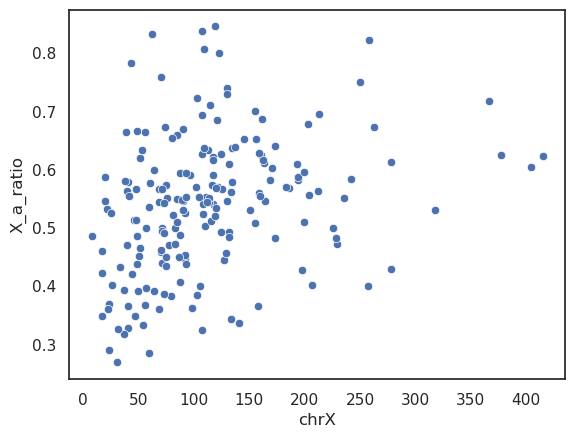

In [52]:
sns.scatterplot(species_with_x_and_tree, x="chrX", y="X_a_ratio")

In [53]:
glm_results = smf.gls(formula = "CV_x ~ CV_aut", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                   CV_x   R-squared:                       0.754
Model:                            GLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     575.5
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           4.08e-59
Time:                        11:13:14   Log-Likelihood:                -26.046
No. Observations:                 190   AIC:                             56.09
Df Residuals:                     188   BIC:                             62.59
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0317      0.427      0.074      0.941      -0.811       0.875
CV_aut         1.1911      0.050     23.990      0.000       1.093       1.289
==============================================================================
Omnibus:                       74.594   Durbin-Watson:                   2.268
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              670.276
Skew:                          -1.186   Prob(JB):                    2.83e-146
Kurtosis:                      11.890   Cond. No.                         8.63
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [54]:
species_with_x_and_tree

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,Strategy_count,Monogamous_strategy,Polygynous_strategy,Polygynandrous_strategy,Polyandrous_strategy,Binomial name,Primary_strategy
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.429676,0.842548,0.001380,0.000761,0.551049,0.551049,Allenopithecus_nigroviridis,1.0,0.0,0.0,1.0,0.0,Allenopithecus nigroviridis,Polygynandrous
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.512099,0.921961,0.002712,0.000983,0.362366,0.362366,Allochrocebus_lhoesti,3.0,0.0,1.0,0.0,0.0,Allochrocebus lhoesti,Polygynous
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.698784,0.959003,0.002649,0.001059,0.399758,0.399758,Allochrocebus_preussi,1.0,0.0,1.0,0.0,0.0,Allochrocebus preussi,Polygynous
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.266829,0.268274,0.005102,0.003662,0.717838,0.717838,Alouatta_belzebul,1.0,0.0,1.0,0.0,0.0,Alouatta belzebul,Polygynous
6,Alouatta_discolor_ssp,206.429698,108.086733,0.604936,0.623321,0.002064,0.001081,0.523601,0.523601,Alouatta_discolor,1.0,0.0,1.0,0.0,0.0,Alouatta discolor,Polygynous
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Trachypithecus_pileatus_ssp,110.758378,59.386733,0.762625,0.921115,0.001108,0.000594,0.536183,0.536183,Trachypithecus_pileatus,2.0,0.0,1.0,0.0,0.0,Trachypithecus pileatus,Polygynous
246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.712469,0.680886,0.000655,0.000380,0.580929,0.580929,Trachypithecus_poliocephalus,NaN,NaN,NaN,NaN,NaN,Trachypithecus poliocephalus,Unknown
247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.430623,0.522426,0.002328,0.001347,0.578665,0.578665,Trachypithecus_vetulus,NaN,NaN,NaN,NaN,NaN,Trachypithecus vetulus,Unknown
249,Varecia_variegata_ssp,211.144432,120.002801,0.422388,0.614984,0.002111,0.001200,0.568345,0.568345,Varecia_variegata,5.0,0.6,0.0,0.2,0.2,Varecia variegata,Monogamous


In [55]:
# If you are using CV of chromosome X, CV of autosomes have no information.
glm_results = smf.gls(formula = "X_a_ratio ~ aut*CV_aut+aut*CV_x", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.300
Model:                            GLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     15.77
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           6.47e-13
Time:                        11:13:14   Log-Likelihood:                 111.18
No. Observations:                 190   AIC:                            -210.4
Df Residuals:                     184   BIC:                            -190.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5580      0.212      2.630      0.009       0.139       0.976
aut            0.0006      0.000      3.693      0.000       0.000       0.001
CV_aut         0.0446      0.059      0.755      0.451      -0.072       0.161
aut:CV_aut  2.195e-07      0.000      0.001      1.000      -0.001       0.001
CV_x          -0.0587      0.050     -1.168      0.244      -0.158       0.040
aut:CV_x      -0.0009      0.000     -3.649      0.000      -0.001      -0.000
==============================================================================
Omnibus:                      100.691   Durbin-Watson:                   1.774
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1321.541
Skew:                          -1.628   Prob(JB):                    1.07e-287
Kurtosis:                      15.503   Cond. No.                     4.61e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.61e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [56]:
# Mating strategy does not seem to affect X/A Ratio
glm_results = smf.gls(formula = "X_a_ratio ~ Primary_strategy+aut*CV_x", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.309
Model:                            GLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     11.63
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           3.46e-12
Time:                        11:13:14   Log-Likelihood:                 112.41
No. Observations:                 190   AIC:                            -208.8
Df Residuals:                     182   BIC:                            -182.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
======================================================================================================
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              0.5282      0.213      2.475      0.014       0.107       0.949
Primary_strategy[T.Polyandrous]        0.0089      0.046      0.192      0.848      -0.083       0.101
Primary_strategy[T.Polygynandrous]     0.0286      0.031      0.928      0.355      -0.032       0.090
Primary_strategy[T.Polygynous]         0.0430      0.030      1.413      0.159      -0.017       0.103
Primary_strategy[T.Unknown]            0.0392      0.026      1.531      0.128      -0.011       0.090
aut                                    0.0007      0.000      4.200      0.000       0.000       0.001
CV_x                                  -0.0241      0.031     -0.768      0.443      -0.086       0.038
aut:CV_x                              -0.0009      0.000     -4.989      0.000      -0.001      -0.001
==============================================================================
Omnibus:                      100.702   Durbin-Watson:                   1.745
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1417.907
Skew:                          -1.601   Prob(JB):                    1.27e-308
Kurtosis:                      15.994   Cond. No.                     4.42e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.42e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [57]:
dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group))

{'Allenopithecus_nigroviridis_ssp': 'OWM',
 'Aotus_azarai_ssp': 'PLA',
 'Aotus_griseimembra_ssp': 'PLA',
 'Aotus_nancymaae_ssp': 'PLA',
 'Aotus_trivirgatus_ssp': 'PLA',
 'Aotus_vociferans_ssp': 'PLA',
 'Alouatta_belzebul_ssp': 'PLA',
 'Alouatta_caraya_ssp': 'PLA',
 'Alouatta_discolor_ssp': 'PLA',
 'Alouatta_juara_ssp': 'PLA',
 'Alouatta_macconnelli_ssp': 'PLA',
 'Alouatta_palliata_ssp': 'PLA',
 'Alouatta_seniculus_ssp': 'PLA',
 'Ateles_belzebuth_ssp': 'PLA',
 'Ateles_chamek_ssp': 'PLA',
 'Ateles_geoffroyi_ssp': 'PLA',
 'Ateles_marginatus_ssp': 'PLA',
 'Ateles_paniscus_ssp': 'PLA',
 'Brachyteles_hypoxanthus_ssp': 'PLA',
 'Lagothrix_lagotricha_ssp': 'PLA',
 'Callimico_goeldii_ssp': 'PLA',
 'Callithrix_geoffroyi_ssp': 'PLA',
 'Callithrix_jacchus_ssp': 'PLA',
 'Callithrix_kuhlii_ssp': 'PLA',
 'Cebuella_niveiventris_ssp': 'PLA',
 'Cebuella_pygmaea_ssp': 'PLA',
 'Mico_argentatus_ssp': 'PLA',
 'Mico_humeralifer_ssp': 'PLA',
 'Mico_humilis_ssp': 'PLA',
 'Carlito_syrichta_ssp': 'TAR',
 'Cephalo

In [58]:
species_with_x_and_tree["group"] = species_with_x_and_tree.species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))

/tmp/36627705/ipykernel_140972/2820848254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree["group"] = species_with_x_and_tree.species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))


In [59]:
glm_results = smf.gls(formula = "X_a_ratio ~ aut:group+aut*CV_x", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.323
Model:                            GLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     14.56
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           1.45e-13
Time:                        11:13:14   Log-Likelihood:                 114.38
No. Observations:                 190   AIC:                            -214.8
Df Residuals:                     183   BIC:                            -192.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.6147      0.211      2.915      0.004       0.199       1.031
aut                  0.0003      0.001      0.589      0.557      -0.001       0.001
aut:group[T.OWM]  5.685e-05      0.001      0.104      0.918      -0.001       0.001
aut:group[T.PLA]     0.0004      0.001      0.756      0.451      -0.001       0.002
aut:group[T.STR]     0.0004      0.001      0.706      0.481      -0.001       0.001
CV_x                -0.0400      0.031     -1.287      0.200      -0.101       0.021
aut:CV_x            -0.0010      0.000     -4.943      0.000      -0.001      -0.001
==============================================================================
Omnibus:                       97.505   Durbin-Watson:                   1.746
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1579.613
Skew:                          -1.476   Prob(JB):                         0.00
Kurtosis:                      16.814   Cond. No.                     5.14e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.14e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

I also performed this regression in caper with a kappa of 2. R-square there was 0.31.
However, it's not possible to combine quantitative and qualitative variables in caper.
Below I check whether the distribution of 1-2 and 3+ populations differ.

In [60]:
s_count = []
for s in species_with_x_and_tree.species:
    s_count.append(len(metadata_20x_filt.loc[metadata_20x_filt.species_genotyping == s]))
species_with_x_and_tree["sample_count"] = s_count

/tmp/36627705/ipykernel_140972/3348411378.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree["sample_count"] = s_count


In [61]:
species_with_x_and_tree.sort_values(["Binomial name"]).sample_count

161    94
160    15
90     29
89     20
190    16
       ..
87      2
86      2
159     3
158     2
88      1
Name: sample_count, Length: 190, dtype: int64

<Axes: xlabel='sample_count', ylabel='X_a_ratio'>

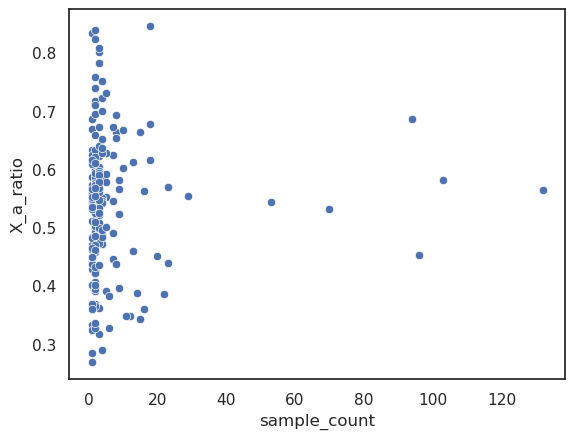

In [62]:
sns.scatterplot(species_with_x_and_tree, x="sample_count", y="X_a_ratio")

In [63]:
species_with_x_and_tree.sample_count.median()

2.5

<Axes: xlabel='X_a_ratio', ylabel='Count'>

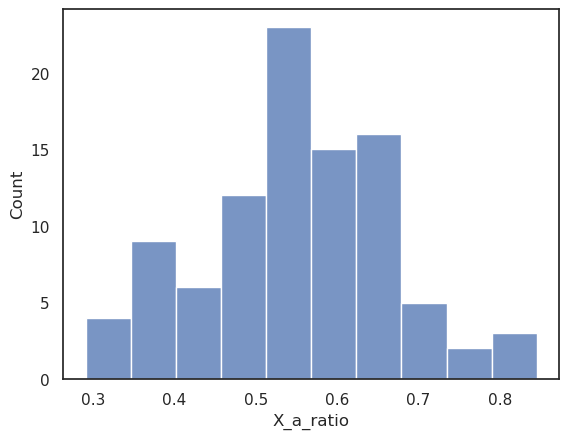

In [64]:
sns.histplot(species_with_x_and_tree.loc[species_with_x_and_tree.sample_count >= 3], x="X_a_ratio")

<Axes: xlabel='X_a_ratio', ylabel='Count'>

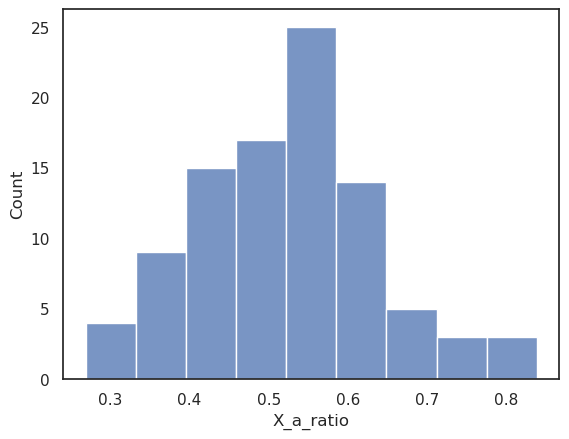

In [65]:
sns.histplot(species_with_x_and_tree.loc[species_with_x_and_tree.sample_count < 3], x="X_a_ratio")

In [66]:
species_with_x_and_tree.loc[species_with_x_and_tree.sample_count >= 3].X_a_ratio.mean(), species_with_x_and_tree.loc[species_with_x_and_tree.sample_count < 3].X_a_ratio.mean()

(0.5536085865449902, 0.5234882852999322)

In [67]:
species_with_x_and_tree.loc[species_with_x_and_tree.sample_count >= 3].X_a_ratio.var(), species_with_x_and_tree.loc[species_with_x_and_tree.sample_count < 3].X_a_ratio.var()

(0.013268050678605944, 0.013842521351567553)

In [68]:
glm_results = smf.gls(formula = "X_a_ratio ~ aut*CV_aut", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.164
Model:                            GLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     12.13
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           2.74e-07
Time:                        11:13:14   Log-Likelihood:                 94.272
No. Observations:                 190   AIC:                            -180.5
Df Residuals:                     186   BIC:                            -167.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5678      0.230      2.471      0.014       0.115       1.021
aut            0.0006      0.000      3.567      0.000       0.000       0.001
CV_aut        -0.0286      0.040     -0.719      0.473      -0.107       0.050
aut:CV_aut    -0.0012      0.000     -3.421      0.001      -0.002      -0.001
==============================================================================
Omnibus:                       61.224   Durbin-Watson:                   1.811
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              643.998
Skew:                          -0.836   Prob(JB):                    1.44e-140
Kurtosis:                      11.863   Cond. No.                     4.06e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.06e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Adding testes size (and imputation).